* Minh Trinh
* Math 318, Winter 2026
* February 27, 2026

In [349]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import statsmodels packages
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [350]:
# Import ISLP packages
from ISLP import confusion_table
from ISLP.models import contrast
from ISLP.models import (ModelSpec as MS, summarize, poly)

# Import scikit-learn packages
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [351]:
weekly = pd.read_csv('C:/Users/trinh/Desktop/MATH 318-001 Homework/data/Weekly.csv')
weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


# Data Summaries

(a) Produce some numerical and graphical summaries of the `Weekly` data. Do there appear to be any patterns?

In [352]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [353]:
weekly.shape

(1089, 9)

In [354]:
weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [355]:
print(weekly['Direction'].dtypes)

object


In [356]:
# Recast `Direction` as `category` type
weekly['Direction'] = weekly['Direction'].astype('category')
print(weekly['Direction'].dtypes)

category


In [357]:
# Create the design matrix with one-hot encoding for 'Direction'
design = MS(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Direction'], intercept=False)
matrix = design.fit_transform(weekly)

# Create the correlation matrix
matrix.corr()

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Direction[Up]
Lag1,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.050004
Lag2,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.072696
Lag3,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.022913
Lag4,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.020549
Lag5,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,-0.018168
Volume,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.017995
Direction[Up],-0.050004,0.072696,-0.022913,-0.020549,-0.018168,-0.017995,1.000000


<Axes: xlabel='Year', ylabel='Volume'>

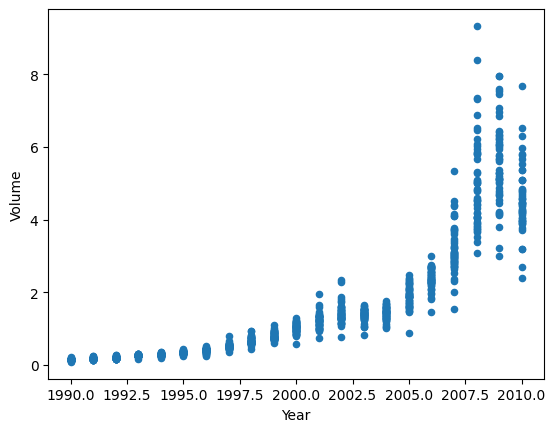

In [358]:
weekly.plot.scatter(x='Year', y='Volume')

The `Weekly` dataset contains 1,089 observations (rows) of stock market returns across nine variables (columns), including five lag variables (`Lag1, Lag2, Lag3, Lag4, Lag5`), trading `Volume`, `Year`, and the daily return (`Today`). The correlation matrix shows that the nine variables are mostly uncorrelated with one another, and the most substantial correlation is between Year and Volume (`corr` = 0.8419416187031639). Scatterlotting the data confirms the pattern, showing that the trading `Volume` is increasing over time from 1990 to 2010. Beyond this trend, there also appears to be a strong correlation between `Lag2` and the market's `Direction[Up]` (`corr` = 0.07269634359428741), that which we will examine further.

# Statistical Significance

(b) Use the full data set to perform a logistic regression with `Direction` as the response and the five lag variables plus `Volume` as predictors. Use the `summary` function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [359]:
# Set 'Direction' as the binary response variable for logistic regression
y = (weekly['Direction'] == 'Up') 

# statsmodels requires the intercept to calculate the constant term, so set intercept=True
design = MS(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume'], intercept=True)
X = design.fit_transform(weekly)

# Fit the logistic regression model
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

In [360]:
# Summarize results
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


In [361]:
# View results summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Fri, 27 Feb 2026   Deviance:                       1486.4
Time:                        12:46:30   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.030       0.006       0.111
Lag3          -0.0161      0.027     -0.602      0.547      -0.068       0.036
Lag4          -0.0278      0.026     -1.050      0.294      -0.080       0.024
Lag5          -0.0145      0.026     -0.549      0.583      -0.066       0.037
Volume        -0.0227      0.037     -0.616      0.538      -0.095       0.050
==============================================================================
"""

Performing a logistic regression with `Direction` as the response and the five lag variables (`Lag1, Lag2, Lag3, Lag4, Lag5`) plus `Volume` as predictors, the results confirm that one of the predictors appears to be statistically significant, `Lag2` with a `p-value` = 0.030 < $\alpha = 0.05$.

# Confusion Matrix

(c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [362]:
# Predict probabilities
probs = results.predict()

# Classify as 'Up' if probability > 0.5, else 'Down' 
labels = np.array(['Down'] * len(weekly['Direction']))
labels[probs > 0.5] = 'Up'

In [363]:
# Create confusion matrix
print(confusion_table(labels, weekly['Direction']))

Truth      Down   Up
Predicted           
Down         54   48
Up          430  557


In [364]:
# Calculate accuracy and error rates
accuracy = np.mean(labels == weekly['Direction'])
error = np.mean(labels != weekly['Direction'])

In [365]:
print(f'Accuracy Rate: {accuracy}')
print(f'Error Rate: {error}')

Accuracy Rate: 0.5610651974288338
Error Rate: 0.4389348025711662


# Logistic Regression (LR)

(d) Now fit the logistic regression model using a training data period from 1990 to 2008, with `Lag2` as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [366]:
# Split data into training and test sets based on the 'Year' variable
train = (weekly['Year'] < 2009)
weekly_train = weekly.loc[train]
weekly_test = weekly.loc[~train]

# Set 'Direction' as the binary response variable for logistic regression
y_train = (weekly_train['Direction'] == 'Up')

# Create the design matrix for training data with only 'Lag2' as predictor
design_lag2 = MS(['Lag2'], intercept=True)
X_train = design_lag2.fit_transform(weekly_train)

# Create the design matrix for test data with only 'Lag2' as predictor
y_test = weekly_test['Direction']

# Avoid data leakage by not refitting on test data
# transform to ensure the same scaling is applied to test and training data
X_test = design_lag2.transform(weekly_test)

In [367]:
# Fit the logistic regression model on the training data
model_lr = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results_lr = model_lr.fit()

# Predict probabilities on the test set
probs_lr = results_lr.predict(X_test)

In [368]:
# Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
labels_lr = np.array(['Down'] * len(y_test))
labels_lr[probs_lr > 0.5] = 'Up'

In [369]:
# Create confusion matrix
print(confusion_table(labels_lr, y_test))

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56


In [370]:
# Calculate accuracy and error rates
accuracy_lr = np.mean(labels_lr == y_test)
error_lr = np.mean(labels_lr != y_test)

In [371]:
# Print accuracy and error rates
print(f'Accuracy Rate: {accuracy_lr}')
print(f'Error Rate: {error_lr}')

Accuracy Rate: 0.625
Error Rate: 0.375


# Linear Discriminant Analysis (LDA)

(e) Repeat (d) using LDA.

In [372]:
# Drop the intercept column from the design matrices for LDA, QDA, and Naive Bayes
X_train, X_test = [M.drop(columns=['intercept']) for M in [X_train, X_test]]

In [373]:
# Initialize LDA model with store_covariance=True
lda = LDA(store_covariance=True)

# Fit the LDA model on the training data
lda.fit(X_train, y_train)

# Predict probabilities on the test set
probs_lda = lda.predict(X_test)

In [374]:
# Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
labels_lda = np.array(['Down'] * len(y_test))
labels_lda[probs_lda > 0.5] = 'Up'

In [375]:
# Create confusion matrix
print(confusion_table(labels_lda, y_test))

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56


In [376]:
# Calculate accuracy and error rates
accuracy_lda = np.mean(labels_lda == y_test)
error_lda = np.mean(labels_lda != y_test)

In [377]:
# Print accuracy and error rates
print(f'Accuracy Rate: {accuracy_lda}')
print(f'Error Rate: {error_lda}')

Accuracy Rate: 0.625
Error Rate: 0.375


# Quadratic Discriminant Analysis (QDA)

(f) Repeat (d) using QDA.

In [378]:
# Initialize QDA model with store_covariance=True
qda = QDA(store_covariance=True)

# Fit the QDA model on the training data
qda.fit(X_train, y_train)

# Predict probabilities on the test set
probs_qda = qda.predict(X_test)

In [379]:
# Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
labels_qda = np.array(['Down'] * len(y_test))
labels_qda[probs_qda > 0.5] = 'Up'

In [380]:
# Create confusion matrix
print(confusion_table(labels_qda, y_test))

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61


In [381]:
# Calculate accuracy and error rates
accuracy_qda = np.mean(labels_qda == y_test)
error_qda = np.mean(labels_qda != y_test)

In [382]:
# Print accuracy and error rates
print(f'Accuracy Rate: {accuracy_qda}')
print(f'Error Rate: {error_qda}')

Accuracy Rate: 0.5865384615384616
Error Rate: 0.41346153846153844


# K-Nearest Neighbors (KNN)

(g) Repeat (d) using KNN with $K=1$.

In [383]:
# Initialize KNeighborsClassifier with n_neighbors=1
knn = KNeighborsClassifier(n_neighbors=1)

# Fit the KNN model on the training data
knn.fit(X_train, y_train)

# Predict probabilities on the test set
probs_knn = knn.predict(X_test)

In [384]:
# Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
labels_knn = np.array(['Down'] * len(y_test))
labels_knn[probs_knn > 0.5] = 'Up'

In [385]:
# Create confusion matrix
print(confusion_table(labels_knn, y_test))

Truth      Down  Up
Predicted          
Down         22  30
Up           21  31


In [386]:
# Calculate accuracy and error rates
accuracy_knn = np.mean(labels_knn == y_test)
error_knn = np.mean(labels_knn != y_test)

In [387]:
# Print accuracy and error rates
print(f'Accuracy Rate: {accuracy_knn}')
print(f'Error Rate: {error_knn}')

Accuracy Rate: 0.5096153846153846
Error Rate: 0.49038461538461536


# Naive Bayes (NB)

(h) Repeat (d) using Naive Bayes.

In [388]:
# Initialize Gaussian Naive Bayes model
nb = GaussianNB()

# Fit the Naive Bayes model on the training data
nb.fit(X_train, y_train)

# Predict probabilities on the test set
probs_nb = nb.predict(X_test)

In [389]:
# Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
labels_nb = np.array(['Down'] * len(y_test))
labels_nb[probs_nb > 0.5] = 'Up'

In [390]:
# Create confusion matrix
print(confusion_table(labels_nb, y_test))

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61


In [391]:
# Calculate accuracy and error rates
accuracy_nb = np.mean(labels_nb == y_test)
error_nb = np.mean(labels_nb != y_test)

In [392]:
# Print accuracy and error rates
print(f'Accuracy Rate: {accuracy_nb}')
print(f'Error Rate: {error_nb}')

Accuracy Rate: 0.5865384615384616
Error Rate: 0.41346153846153844


# Best Methods

(i) Which of these methods appears to provide the best results on this data?

In [393]:
# Save results
comparison = {
    'Model': ['Logistic Regression', 'LDA', 'QDA', 'KNN (K=1)', 'Naive Bayes'],
    'Accuracy Rate': [accuracy_lr, accuracy_lda, accuracy_qda, accuracy_knn, accuracy_nb],
    'Error Rate': [error_lr, error_lda, error_qda, error_knn, error_nb]
}

# Create the summary comparison table
comparison_table = pd.DataFrame(comparison)
comparison_table


,Model,Accuracy Rate,Error Rate
0,Logistic Regression,0.625000,0.375000
1,LDA,0.625000,0.375000
2,QDA,0.586538,0.413462
3,KNN (K=1),0.509615,0.490385
4,Naive Bayes,0.586538,0.413462


Based on the comparison table, using a training data period from 1990 to 2008 with `Lag2` as the only predictor from the `Weekly` dataset, the Logistic Regression and LDA models both provide the best results with the highest accuracy rate (0.625) and the lowest error rate (0.375). QDA and Naive Bayes, perform worse in accuracy (0.5865384615384616) and error (0.41346153846153844). KNN ($K=1$) performs the worst with the lowest accuracy rate (0.5096153846153846) and the highest error rate (0.49038461538461536).

# Experiments

(j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the heldout data. Note that you should also experiment with values for `K` in the KNN classifier.

In [394]:
# Import combinations to generate all possible predictor combinations
from itertools import combinations

In [395]:
# Experiment 1: Evaluate all combinations of lag predictors (Lag1, Lag2, Lag3, Lag4, Lag5)

# Define the full list of potential lag predictors
lags = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']

# Create a list to store all combination results
results_lags = []

# Loop through combination sizes: 1, 2, 3, 4, and 5
for result in range(1, 6):
    # Generate all combinations of the specified size
    for combination in combinations(lags, result):
        combination = list(combination)
        
        # 1. Logistic Regression
        # statsmodels requires the intercept to calculate the constant term, so set intercept=True
        design_log = MS(combination)
        X_train_log = design_log.fit_transform(weekly_train)
        X_test_log = design_log.transform(weekly_test)
        
        # Fit the logistic regression model on the training data
        model_log = sm.GLM(y_train, X_train_log, family=sm.families.Binomial())
        results_log = model_log.fit()
        
        # Predict probabilities on the test set
        probs_log = results_log.predict(X_test_log)

        # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
        labels_log = np.array(['Down'] * len(y_test))
        labels_log[probs_log > 0.5] = 'Up'

        # Calculate accuracy and error rates
        accuracy_log = np.mean(labels_log == weekly_test['Direction'])
        error_log = np.mean(labels_log != weekly_test['Direction'])
        
        # 2. sklearn Models (LDA, QDA, Naive Bayes)
        # sklearn handles intercepts internally, so we set intercept=False
        design_sk = MS(combination, intercept=False)
        X_train_sk = design_sk.fit_transform(weekly_train)
        X_test_sk = design_sk.transform(weekly_test)
        
        # LDA 
        # Fit the LDA model on the training data
        lda = LDA().fit(X_train_sk, y_train)

        # Predict probabilities on the test set
        probs_lda = lda.predict(X_test_sk)

        # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
        labels_lda = np.array(['Down'] * len(y_test))
        labels_lda[probs_lda > 0.5] = 'Up'
        
        # Calculate accuracy and error rates
        accuracy_lda = np.mean(labels_lda == weekly_test['Direction'])
        error_lda = np.mean(labels_lda != weekly_test['Direction'])
        
        # QDA 
        # Fit the QDA model on the training data
        qda = QDA().fit(X_train_sk, y_train)

        # Predict probabilities on the test set
        probs_qda = qda.predict(X_test_sk)

        # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
        labels_qda = np.array(['Down'] * len(y_test))
        labels_qda[probs_qda > 0.5] = 'Up'
        
        # Calculate accuracy and error rates
        accuracy_qda = np.mean(labels_qda == weekly_test['Direction'])
        error_qda = np.mean(labels_qda != weekly_test['Direction'])
        
        # Naive Bayes
        # Fit the Naive Bayes model on the training data
        nb = GaussianNB().fit(X_train_sk, y_train)

        # Predict probabilities on the test set
        probs_nb = nb.predict(X_test_sk)

        # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
        labels_nb = np.array(['Down'] * len(y_test))
        labels_nb[probs_nb > 0.5] = 'Up'

        # Calculate accuracy and error rates
        accuracy_nb = np.mean(labels_nb == weekly_test['Direction'])
        error_nb = np.mean(labels_nb != weekly_test['Direction'])
        
        # Save results
        results_lags.append({
            'Predictors': "+".join(combination),
            'Logistic Error Rate': error_log,
            'LDA Error Rate': error_lda,
            'QDA Error Rate': error_qda,
            'NB Error Rate': error_nb
        })

# Create the summary comparison table
results_lag_table = pd.DataFrame(results_lags)
results_lag_table.sort_values(by='Logistic Error Rate', ascending=True)

,Predictors,Logistic Error Rate,LDA Error Rate,QDA Error Rate,NB Error Rate
1,Lag2,0.375000,0.375000,0.413462,0.413462
9,Lag2+Lag3,0.375000,0.375000,0.394231,0.413462
10,Lag2+Lag4,0.375000,0.375000,0.461538,0.461538
29,Lag2+Lag3+Lag4+Lag5,0.375000,0.375000,0.519231,0.538462
23,Lag2+Lag4+Lag5,0.384615,0.384615,0.528846,0.528846
21,Lag2+Lag3+Lag4,0.384615,0.384615,0.451923,0.442308
22,Lag2+Lag3+Lag5,0.384615,0.384615,0.509615,0.509615
11,Lag2+Lag5,0.394231,0.403846,0.490385,0.519231
16,Lag1+Lag2+Lag4,0.394231,0.394231,0.519231,0.490385
12,Lag3+Lag4,0.413462,0.413462,0.432692,0.413462


In [396]:
# Experiment 2: Evaluate all pairs of lag predictors with interaction terms (Lag1, Lag2, Lag3, Lag4, Lag5)

# Create a list to store interaction results
results_interaction = []

# Generate all pairs of lags to create interaction terms
for pair in combinations(lags, 2):
    # Define predictor = lag pair and its interaction tuple
    # Model example: Direction ~ LagA + LagB + LagA:LagB
    combination = [pair[0], pair[1], (pair[0], pair[1])]
    
    # 1. Logistic Regression
    # statsmodels requires the intercept to calculate the constant term, so set intercept=True
    design_log = MS(combination, intercept=True)
    X_train_log = design_log.fit_transform(weekly_train)
    X_test_log = design_log.transform(weekly_test)
    
    # Fit the logistic regression model on the training data
    model_log = sm.GLM(y_train, X_train_log, family=sm.families.Binomial())
    results_log = model_log.fit()
    
    # Predict probabilities on the test set
    probs_log = results_log.predict(X_test_log)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_log = np.array(['Down'] * len(y_test))
    labels_log[probs_log > 0.5] = 'Up'

    # Calculate accuracy and error rates
    accuracy_log = np.mean(labels_log == weekly_test['Direction'])
    error_log = np.mean(labels_log != weekly_test['Direction'])
    
    # 2. sklearn Models (LDA, QDA, Naive Bayes)
    # sklearn handles intercepts internally, so we set intercept=False
    design_sk = MS(combination, intercept=False)
    X_train_sk = design_sk.fit_transform(weekly_train)
    X_test_sk = design_sk.transform(weekly_test)
    
    # LDA
    # Fit the LDA model on the training data
    lda = LDA().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_lda = lda.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_lda = np.array(['Down'] * len(y_test))
    labels_lda[probs_lda > 0.5] = 'Up'
    
    # Calculate accuracy and error rates
    accuracy_lda = np.mean(labels_lda == weekly_test['Direction'])
    error_lda = np.mean(labels_lda != weekly_test['Direction'])
    
    # QDA
    # Fit the QDA model on the training data
    qda = QDA().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_qda = qda.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_qda = np.array(['Down'] * len(y_test))
    labels_qda[probs_qda > 0.5] = 'Up'
    
    # Calculate accuracy and error rates
    accuracy_qda = np.mean(labels_qda == weekly_test['Direction'])
    error_qda = np.mean(labels_qda != weekly_test['Direction'])
    
    # Naive Bayes
    # Fit the Naive Bayes model on the training data
    nb = GaussianNB().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_nb = nb.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_nb = np.array(['Down'] * len(y_test))
    labels_nb[probs_nb > 0.5] = 'Up'

    # Calculate accuracy and error rates
    accuracy_nb = np.mean(labels_nb == weekly_test['Direction'])
    error_nb = np.mean(labels_nb != weekly_test['Direction'])
    
    # Save all results into the list
    results_interaction.append({
        'Lag Pair': f"{pair[0]}, {pair[1]}",
        'Interaction': f"{pair[0]} * {pair[1]}",
        'Logistic Error Rate': error_log,
        'LDA Error Rate': error_lda,
        'QDA Error Rate': error_qda,
        'NB Error Rate': error_nb
    })

# Create the summary comparison table
results_interaction_table = pd.DataFrame(results_interaction)
results_interaction_table.sort_values(by='Logistic Error Rate', ascending=True)

,Lag Pair,Interaction,Logistic Error Rate,LDA Error Rate,QDA Error Rate,NB Error Rate
4,"Lag2, Lag3",Lag2 * Lag3,0.375000,0.375000,0.423077,0.413462
6,"Lag2, Lag5",Lag2 * Lag5,0.403846,0.403846,0.471154,0.471154
7,"Lag3, Lag4",Lag3 * Lag4,0.403846,0.413462,0.471154,0.490385
2,"Lag1, Lag4",Lag1 * Lag4,0.413462,0.413462,0.471154,0.432692
5,"Lag2, Lag4",Lag2 * Lag4,0.413462,0.413462,0.451923,0.461538
0,"Lag1, Lag2",Lag1 * Lag2,0.423077,0.423077,0.538462,0.528846
1,"Lag1, Lag3",Lag1 * Lag3,0.423077,0.423077,0.490385,0.519231
8,"Lag3, Lag5",Lag3 * Lag5,0.432692,0.432692,0.471154,0.519231
9,"Lag4, Lag5",Lag4 * Lag5,0.442308,0.442308,0.500000,0.500000
3,"Lag1, Lag5",Lag1 * Lag5,0.461538,0.461538,0.451923,0.471154


In [397]:
# Experiment 3: Evaluate polynomials of Lag2 (Degrees 1 through 5)

# Create a list to store polynomial results
results_poly = []

# Loop through polynomials of Lag2 (Degrees 1 through 5)
for d in range(1, 6):
    # Define separate predictors for logistic regression and sklearn models
    # Avoid data leakage by not refitting on test data
    combination_log = [poly('Lag2', degree=d)]
    combination_sk = [poly('Lag2', degree=d)]
    
    # 1. Logistic Regression
    # statsmodels requires the intercept to calculate the constant term
    design_log = MS(combination_log, intercept=True)
    X_train_log = design_log.fit_transform(weekly_train)
    X_test_log = design_log.transform(weekly_test)
    
    # Fit the logistic regression model on the training data
    model_log = sm.GLM(y_train, X_train_log, family=sm.families.Binomial())
    results_log = model_log.fit()
    
    # Predict probabilities on the test set
    probs_log = results_log.predict(X_test_log)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_log = np.array(['Down'] * len(y_test))
    labels_log[probs_log > 0.5] = 'Up'

    # Calculate accuracy and error rates
    accuracy_log = np.mean(labels_log == weekly_test['Direction'])
    error_log = np.mean(labels_log != weekly_test['Direction'])
    
    # 2. sklearn Models (LDA, QDA, Naive Bayes)
    # sklearn handles intercepts internally, so we set intercept=False
    design_sk = MS(combination_sk, intercept=False)
    X_train_sk = design_sk.fit_transform(weekly_train)
    X_test_sk = design_sk.transform(weekly_test)
    
    # LDA
    # Fit the LDA model on the training data
    lda = LDA().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_lda = lda.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_lda = np.array(['Down'] * len(y_test))
    labels_lda[probs_lda > 0.5] = 'Up'
    
    # Calculate accuracy and error rates
    accuracy_lda = np.mean(labels_lda == weekly_test['Direction'])
    error_lda = np.mean(labels_lda != weekly_test['Direction'])
    
    # QDA
    # Fit the QDA model on the training data
    qda = QDA().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_qda = qda.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_qda = np.array(['Down'] * len(y_test))
    labels_qda[probs_qda > 0.5] = 'Up'
    
    # Calculate accuracy and error rates
    accuracy_qda = np.mean(labels_qda == weekly_test['Direction'])
    error_qda = np.mean(labels_qda != weekly_test['Direction'])
    
    # Naive Bayes
    # Fit the Naive Bayes model on the training data
    nb = GaussianNB().fit(X_train_sk, y_train)

    # Predict probabilities on the test set
    probs_nb = nb.predict(X_test_sk)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_nb = np.array(['Down'] * len(y_test))
    labels_nb[probs_nb > 0.5] = 'Up'

    # Calculate accuracy and error rates
    accuracy_nb = np.mean(labels_nb == weekly_test['Direction'])
    error_nb = np.mean(labels_nb != weekly_test['Direction'])
    
    # Save results
    results_poly.append({
        'Degree': d,
        'Logistic Error Rate': error_log,
        'LDA Error Rate': error_lda,
        'QDA Error Rate': error_qda,
        'NB Error Rate': error_nb
    })

# Create the summary comparison table
results_poly_table = pd.DataFrame(results_poly)
results_poly_table.sort_values(by='Logistic Error Rate', ascending=True)

,Degree,Logistic Error Rate,LDA Error Rate,QDA Error Rate,NB Error Rate
0,1,0.375000,0.375000,0.413462,0.413462
1,2,0.375000,0.384615,0.375000,0.432692
2,3,0.413462,0.413462,0.413462,0.423077
3,4,0.413462,0.413462,0.413462,0.432692
4,5,0.413462,0.413462,0.413462,0.557692


In [ ]:
# Experiment 4: Tune KNN by evaluating different K values (K = 1, 2, 3, 4, 5)

# Create a list to store KNN tuning results
results_knn = []

# Using Lag2 as the predictor from Experiment 2
for k in range(1, 6):
    # Initialize KNN with the current K value
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the KNN model on the training data
    model_knn = knn.fit(X_train, y_train)

    # Predict probabilities on the test set
    probs_knn = knn.predict(X_test)

    # Create label array: Initialize as 'Down' and update 'Up' where prob > 0.5
    labels_knn = np.array(['Down'] * len(y_test))
    labels_knn[probs_knn > 0.5] = 'Up'

    # Calculate accuracy and error rates
    accuracy_knn = np.mean(labels_knn == y_test)
    error_knn = np.mean(labels_knn != y_test)

    # Save results
    results_knn.append({
        'K': k, 
        'KNN Error Rate': error_knn})

# Create the summary comparison table
results_knn_table = pd.DataFrame(results_knn)
results_knn_table.sort_values(by='KNN Error Rate', ascending=True)

,K,KNN Error Rate
3,4,0.423077
2,3,0.451923
4,5,0.461538
0,1,0.490385
1,2,0.528846


* Based on the comparison table in Experiment 1, Logistic Regression and LDA remain the most effective methods, with the best performance being achieved using `Lag2` alone and in combination with `Lag3`, yielding an error rate of 0.375. The full model using five lag variables (`Lag1, Lag2, Lag3, Lag4, Lag5`) resulted in a higher error rate of 0.4519230769230769, showing that extra predictors likely introduced more noise.

* Based on the comparison table in Experiment 2, Logistic Regression and LDA remain the best models, with the best performance being achieved using the iteraction between `Lag2*Lag3`, yielding an error rate of 0.375. Other interactions, however, significantly worsened the error rate.

* Based on the comparison table in Experiment 3, more complex, higher-degree models did not fit the test data well. Linear models (i.e. Logistic Regression and LDA) remain the best, yielding an error rate of 0.375. As the degree increased to 5, the error rate for all the models increased.

* Based on the comparison table in Experiment 4, tuning the KNN classifier from $1-5$, $K=4$ performed the best, yielding an error rate of 0.4230769230769231. Despite this, the Logistic Regression and LDA models using only `Lag2` still provided the overall best results.